# 06 — Noise Models: Depolarizing, Phase Damping, Readout

**Purpose.** Evaluate each of the 8 trained VQC checkpoints
(`05_train_all_seeds.ipynb`) under three NISQ noise types --
depolarizing, phase damping, and readout error, each at 4 intensity
levels (L1-L4, plus L0 = ideal and one combined depolarizing+readout
condition) -- via Qiskit Aer, at **inference time only** (checkpoints
are not retrained under noise, per the thesis architecture). Directly
answers sub-RQ(a) (which noise type has the greatest impact on
robustness) and sub-RQ(b)/(c) groundwork (noise intensity vs.
accuracy).

**Noise levels** (`src/noise/levels.py`): kept comparable in
order-of-magnitude across noise types so a type-vs-type comparison
isn't confounded by mismatched severity. L2 matches the archived 06A
notebook's original defaults.

| Level | Depolarizing (p1/p2) | Phase damping (γ) | Readout (p) |
|---|---|---|---|
| L0 | 0 / 0 | 0 | 0 |
| L1 | 0.0005 / 0.005 | 0.005 | 0.01 |
| L2 | 0.001 / 0.01 | 0.01 | 0.02 |
| L3 | 0.005 / 0.03 | 0.03 | 0.05 |
| L4 | 0.01 / 0.05 | 0.05 | 0.10 |

**Pipeline** (`src/noise/`, `src/experiments/evaluate_noise_sweep.py`):
noise models are built via `qiskit_aer.noise` on a fixed, explicit
basis (`rz`/`sx`/`x`/`cx` -- confirmed this circuit decomposes cleanly
to it, 75 rz + 48 sx + 36 cx gates), rather than the archived 06A
notebook's un-transpiled `p`/`ry`/`h`/`cx` basis (which breaks silently
if the circuit changes). The qubit measured by the trained observable
is derived once from `get_measured_qubits()` (the canonical source of
truth -- 06A had two cells silently disagree on this) rather than
re-derived per call site. The whole pipeline was validated against
the exact `StatevectorEstimator`-based model before use (100%
prediction agreement, 0.998 correlation at high shot count under
`noise_model=None`) -- see `tests/test_aer_inference.py`.

Shot-based noisy inference turned out to be fast (~6-9ms/sample,
unlike training's ~30-45 min/epoch), so this runs on the **full**
2956-sample test set for every seed/condition, not a subsample --
112 (seed, condition) evaluations in ~48 minutes total.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Work\Quantum-Adversarial-Robustness


## Results (8 seeds x 14 conditions)

In [2]:
df = pd.read_csv(PROJECT_ROOT / "results" / "noise_sweep" / "noise_sweep_all_seeds.csv")
print("rows:", len(df))

summary = df.groupby(["noise_type", "level"])[["accuracy", "precision", "recall", "f1"]].agg(["mean", "std"])
print(summary.round(4))

rows: 112
                    accuracy         precision          recall          \
                        mean     std      mean     std    mean     std   
noise_type    level                                                      
combined      L2      0.6223  0.0071    0.6320  0.0113  0.7006  0.0566   
depolarizing  L1      0.6245  0.0064    0.6322  0.0095  0.7082  0.0450   
              L2      0.6225  0.0067    0.6320  0.0110  0.7014  0.0523   
              L3      0.6058  0.0097    0.6322  0.0240  0.6398  0.1177   
              L4      0.5507  0.0164    0.6041  0.0273  0.4974  0.2097   
none          L0      0.6259  0.0071    0.6326  0.0097  0.7126  0.0375   
phase_damping L1      0.6253  0.0067    0.6324  0.0093  0.7106  0.0410   
              L2      0.6242  0.0071    0.6324  0.0098  0.7063  0.0473   
              L3      0.6193  0.0107    0.6323  0.0134  0.6872  0.0772   
              L4      0.6092  0.0100    0.6341  0.0230  0.6456  0.1120   
readout       L1      0.6258

**Result:** a clean, monotonic dose-response for depolarizing and
phase damping noise, and an essentially flat response for readout
error:

- **Depolarizing**: 62.45% (L1) -> 55.07% (L4), a 7.5-point drop,
  approaching the ~53% majority-class floor at the stress-test level.
  Variance across seeds also grows with noise level (std 0.64pt at L1
  -> 1.64pt at L4) -- noise doesn't just lower mean accuracy, it makes
  outcomes less predictable.
- **Phase damping**: 62.53% (L1) -> 60.92% (L4), a milder 1.7-point
  drop.
- **Readout**: 62.58% (L1) -> 62.36% (L4), effectively no degradation
  (0.2 points) across the entire sweep.
- **Combined** (depolarizing+readout @ L2): 62.23%, matching
  depolarizing-alone-at-L2 (62.25%) almost exactly -- confirms
  readout's marginal contribution is negligible even stacked with
  another noise source.

**Answer to sub-RQ(a):** depolarizing noise has by far the greatest
impact on this VQC's accuracy, phase damping a moderate impact, and
readout error essentially none, consistently across all 8 independently
trained seeds.

## Accuracy vs. noise level, by noise type

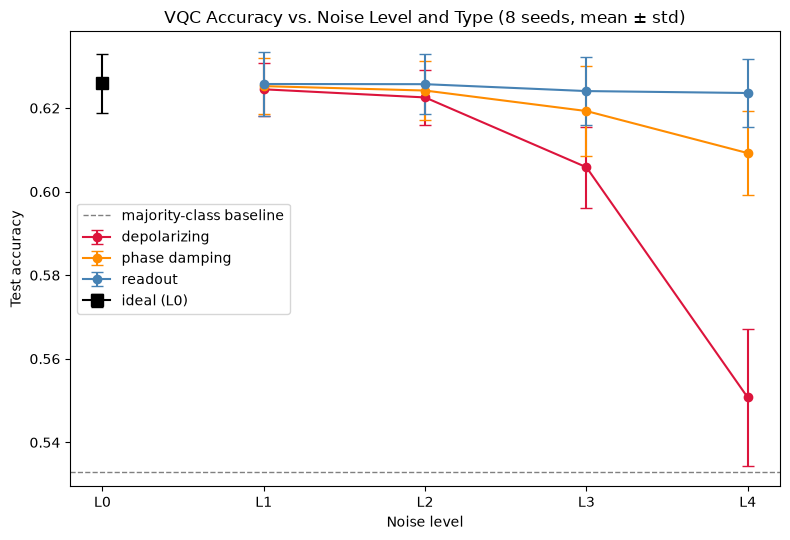

In [3]:
fig, ax = plt.subplots(figsize=(8, 5.5))

level_order = ["L0", "L1", "L2", "L3", "L4"]
level_x = {lvl: i for i, lvl in enumerate(level_order)}

ideal_mean = df[df["noise_type"] == "none"]["accuracy"].mean()
ideal_std = df[df["noise_type"] == "none"]["accuracy"].std()

colors = {"depolarizing": "crimson", "phase_damping": "darkorange", "readout": "steelblue"}

for noise_type in ["depolarizing", "phase_damping", "readout"]:
    sub = df[df["noise_type"] == noise_type]
    grouped = sub.groupby("level")["accuracy"].agg(["mean", "std"]).reindex(["L1", "L2", "L3", "L4"])
    xs = [level_x[lvl] for lvl in grouped.index]
    ax.errorbar(xs, grouped["mean"], yerr=grouped["std"], marker="o", capsize=4,
                label=noise_type.replace("_", " "), color=colors[noise_type])

ax.errorbar([0], [ideal_mean], yerr=[ideal_std], marker="s", markersize=8,
            color="black", capsize=4, label="ideal (L0)")

ax.set_xticks(range(len(level_order)))
ax.set_xticklabels(level_order)
ax.set_xlabel("Noise level")
ax.set_ylabel("Test accuracy")
ax.set_title("VQC Accuracy vs. Noise Level and Type (8 seeds, mean ± std)")
ax.axhline(0.5328, color="gray", linestyle="--", linewidth=1, label="majority-class baseline")
ax.legend()

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "results" / "noise_sweep" / "accuracy_vs_noise_level.png", dpi=150)
plt.show()

## Loss stability and confidence variance

The thesis proposal (Section 4.6) names five metrics to report:
*"classification accuracy, attack success rate, robustness accuracy,
loss stability, and confidence variance."* The first three are covered
throughout this notebook and `07`-`10`. This section covers the last
two, which specifically require **repeated** evaluations of the same
fixed checkpoint on the same fixed inputs under the same (stochastic)
noise condition, varying only the Aer shot-sampling seed
(`src/experiments/evaluate_stability_sweep.py`) -- this isolates
shot-noise-induced instability from cross-seed *training* variance,
which is a different, already-covered axis (the std columns
throughout this notebook and `05_train_all_seeds`).

Representative condition: depolarizing L2 and L4 (the levels also used
in `09_mitigation`), 100-sample subsample, 10 repeats per sample
(1024 shots each), all 8 trained checkpoints.

In [4]:
stability_df = pd.read_csv(PROJECT_ROOT / "results" / "stability_sweep" / "stability_sweep_all_seeds.csv")
print(stability_df.groupby("level")[
    ["mean_confidence_variance", "mean_loss_coefficient_of_variation", "mean_loss"]
].agg(["mean", "std"]).round(5))

      mean_confidence_variance          mean_loss_coefficient_of_variation  \
                          mean      std                               mean   
level                                                                        
L2                     0.00037  0.00006                            0.05678   
L4                     0.00041  0.00006                            0.05712   

               mean_loss           
           std      mean      std  
level                              
L2     0.00503   0.66226  0.01211  
L4     0.00471   0.68936  0.00159  


**Result:** both metrics are small and, notably, barely change
between L2 and L4 (confidence variance 0.00037 -> 0.00041; loss
coefficient of variation 5.68% -> 5.71%) -- despite mean loss itself
rising substantially (0.662 -> 0.689, consistent with the accuracy
degradation already seen earlier in this notebook). This is a useful
methodological separation: **shot-sampling noise contributes a small,
roughly constant amount of run-to-run instability regardless of the
physical noise level**, while the physical noise itself is what drives
the actual accuracy/loss degradation (a systematic shift, not
increased variance). In other words, the accuracy drop reported
throughout this thesis as noise level increases is a real effect of
the noise on the model's decision function, not an artifact of
insufficient shot count -- and 1024 shots (used throughout every sweep
in this project) is an adequate choice, not a significant source of
unreliability in the reported results.

## Next

`07_fgsm_attack.ipynb` implements FGSM via the Adversarial Robustness
Toolbox (per the thesis proposal) and sweeps epsilon against the clean
(noiseless) model. `08_noise_attack_sweep.ipynb` then composes noise
and adversarial attacks together (adversarial examples generated
against the clean model's gradient, evaluated under each noise
condition here) to answer sub-RQ(a)/(b) for adversarial robustness
specifically -- this notebook only established the noise-only
accuracy picture.